In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
(img_train, lbl_train), (img_test, lbl_test) = cifar10.load_data()

print("Train images shape:", img_train.shape)
print("Test images shape: ", img_test.shape)
print("Pixel value range: ", img_train.min(), "-", img_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train images shape: (50000, 32, 32, 3)
Test images shape:  (10000, 32, 32, 3)
Pixel value range:  0 - 255


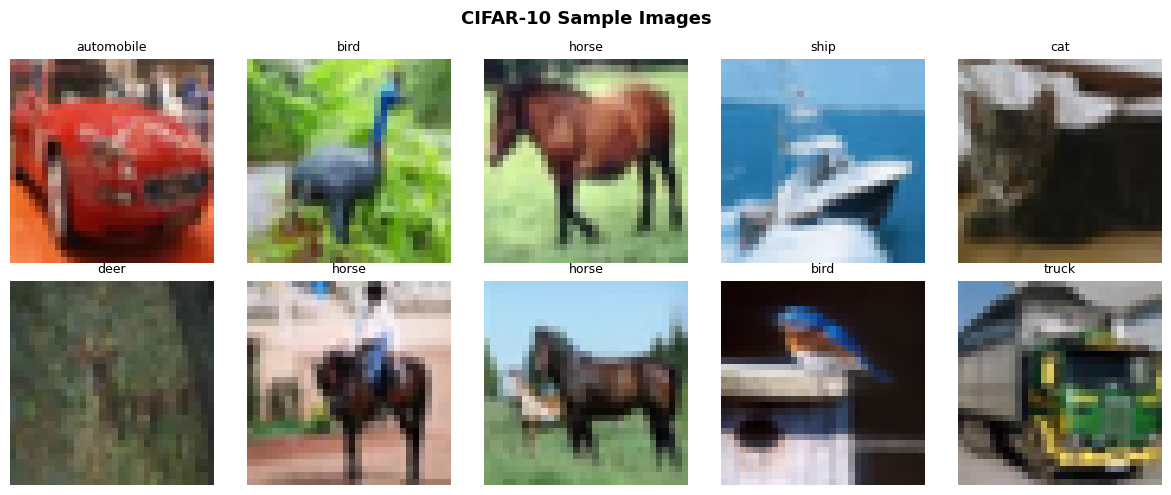

In [3]:
categories = ['airplane', 'automobile', 'bird', 'cat', 'deer',
              'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=13, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    ax.imshow(img_train[idx + 5])
    ax.set_title(categories[lbl_train[idx + 5][0]], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
img_train = img_train.astype('float32') / 255.0
img_test  = img_test.astype('float32')  / 255.0

lbl_train_enc = to_categorical(lbl_train, num_classes=10)
lbl_test_enc  = to_categorical(lbl_test,  num_classes=10)

print("Normalized. New pixel range:", img_train.min(), "-", img_train.max())

Normalized. New pixel range: 0.0 - 1.0


In [5]:
X_tr, X_val, Y_tr, Y_val = train_test_split(
    img_train, lbl_train_enc,
    test_size=0.15,
    random_state=7
)

print("Training samples  :", X_tr.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples  : 42500
Validation samples: 7500


In [6]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
train_log = cnn_model.fit(
    X_tr, Y_tr,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 141s 206ms/step - accuracy: 0.3870 - loss: 1.8378 - val_accuracy: 0.4636 - val_loss: 1.6598
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 134s 201ms/step - accuracy: 0.5806 - loss: 1.1781 - val_accuracy: 0.5887 - val_loss: 1.1878
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 133s 201ms/step - accuracy: 0.6737 - loss: 0.9326 - val_accuracy: 0.6667 - val_loss: 0.9462
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 146s 207ms/step - accuracy: 0.7112 - loss: 0.8175 - val_accuracy: 0.7240 - val_loss: 0.8016
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 136s 199ms/step - accuracy: 0.7555 - loss: 0.6973 - val_accuracy: 0.6551 - val_loss: 1.0064
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 133s 199ms/step - accuracy: 0.7936 - loss: 0.5968 - val_accuracy: 0.6763 - val_loss: 1.0221
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 133s 200ms/step - accuracy: 0.8156 - loss: 0.5222 - val_accuracy: 0.6889 - val_loss: 0.9909
Epoch 8/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 136s 204ms/step - accuracy: 0.8345 -

In [9]:
eval_loss, eval_acc = cnn_model.evaluate(img_test, lbl_test_enc, verbose=0)
print(f"Test Loss     : {eval_loss:.4f}")
print(f"Test Accuracy : {eval_acc * 100:.2f}%")

Test Loss     : 0.9699
Test Accuracy : 75.87%


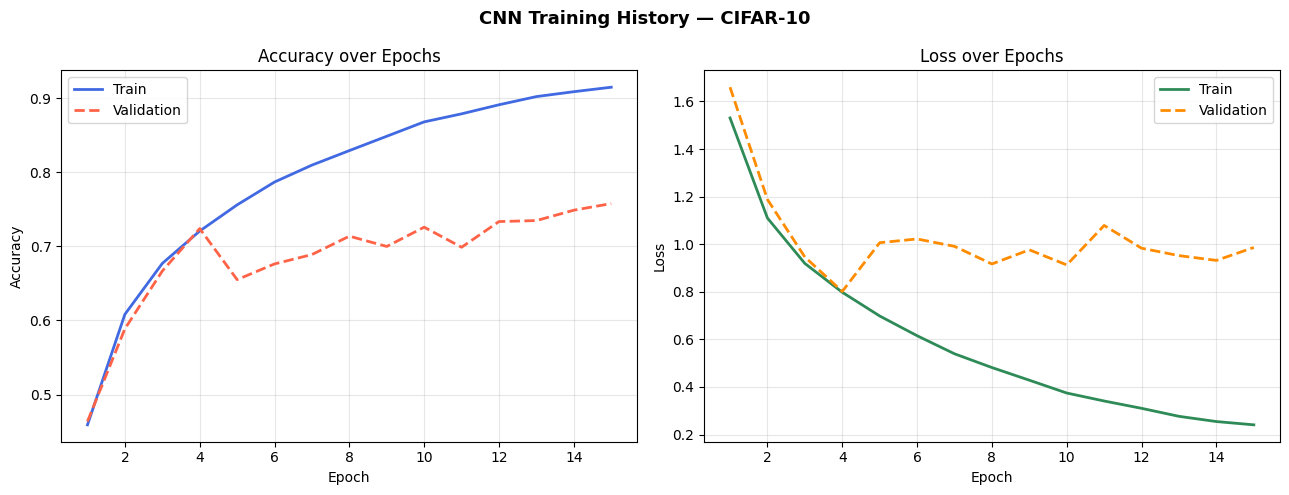

In [10]:
ep = range(1, len(train_log.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CNN Training History — CIFAR-10', fontsize=13, fontweight='bold')

ax1.plot(ep, train_log.history['accuracy'],    color='royalblue',  lw=2, label='Train')
ax1.plot(ep, train_log.history['val_accuracy'], color='tomato',     lw=2, linestyle='--', label='Validation')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, train_log.history['loss'],     color='seagreen',   lw=2, label='Train')
ax2.plot(ep, train_log.history['val_loss'], color='darkorange',  lw=2, linestyle='--', label='Validation')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
raw_preds   = cnn_model.predict(img_test)
pred_labels = np.argmax(raw_preds, axis=1)
true_labels = np.argmax(lbl_test_enc, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


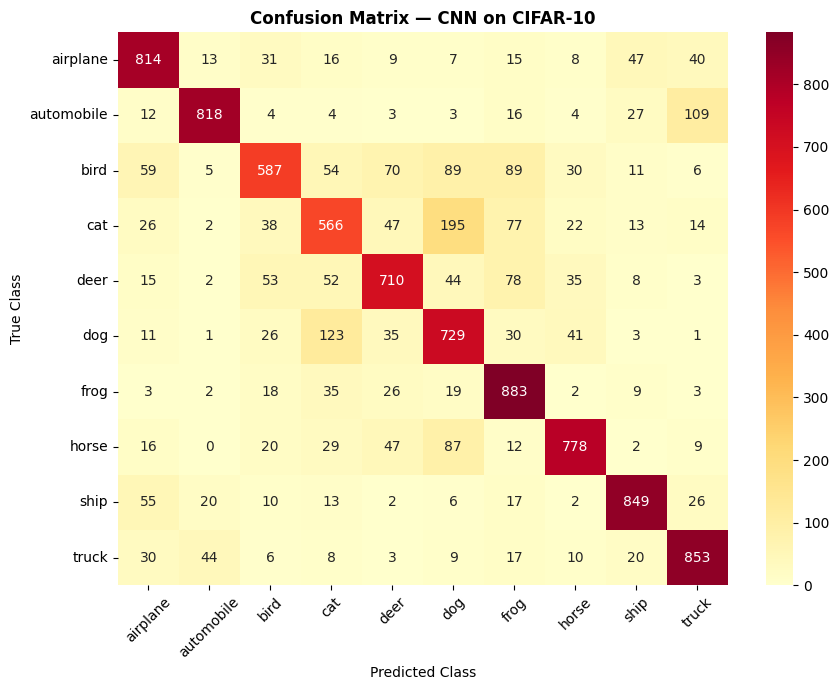

In [12]:
conf_mat = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix — CNN on CIFAR-10', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
print(classification_report(true_labels, pred_labels, target_names=categories))

              precision    recall  f1-score   support

    airplane       0.78      0.81      0.80      1000
  automobile       0.90      0.82      0.86      1000
        bird       0.74      0.59      0.65      1000
         cat       0.63      0.57      0.60      1000
        deer       0.75      0.71      0.73      1000
         dog       0.61      0.73      0.67      1000
        frog       0.72      0.88      0.79      1000
       horse       0.83      0.78      0.81      1000
        ship       0.86      0.85      0.85      1000
       truck       0.80      0.85      0.83      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



In [14]:
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

print("MobileNetV2 base loaded. Trainable:", base.trainable)
print("Total layers in base:", len(base.layers))

/tmp/ipykernel_391/2712246769.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base loaded. Trainable: False
Total layers in base: 154


In [15]:
tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
tl_log = tl_model.fit(
    X_tr, Y_tr,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 61s 82ms/step - accuracy: 0.2253 - loss: 2.1528 - val_accuracy: 0.2945 - val_loss: 1.9417
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 75s 72ms/step - accuracy: 0.3034 - loss: 1.9290 - val_accuracy: 0.3075 - val_loss: 1.9015
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step - accuracy: 0.3210 - loss: 1.8829 - val_accuracy: 0.3160 - val_loss: 1.8825
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.3244 - loss: 1.8651 - val_accuracy: 0.3205 - val_loss: 1.8692
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step - accuracy: 0.3347 - loss: 1.8429 - val_accuracy: 0.3267 - val_loss: 1.8586
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 48s 72ms/step - accuracy: 0.3325 - loss: 1.8405 - val_accuracy: 0.3284 - val_loss: 1.8498
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 48s 72ms/step - accuracy: 0.3395 - loss: 1.8240 - val_accuracy: 0.3323 - val_loss: 1.8454
Epoch 8/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.3385 - loss: 1.8236 - 

In [17]:
tl_loss, tl_acc = tl_model.evaluate(img_test, lbl_test_enc, verbose=0)
print(f"Transfer Learning — Test Loss    : {tl_loss:.4f}")
print(f"Transfer Learning — Test Accuracy: {tl_acc * 100:.2f}%")

Transfer Learning — Test Loss    : 1.8014
Transfer Learning — Test Accuracy: 34.93%


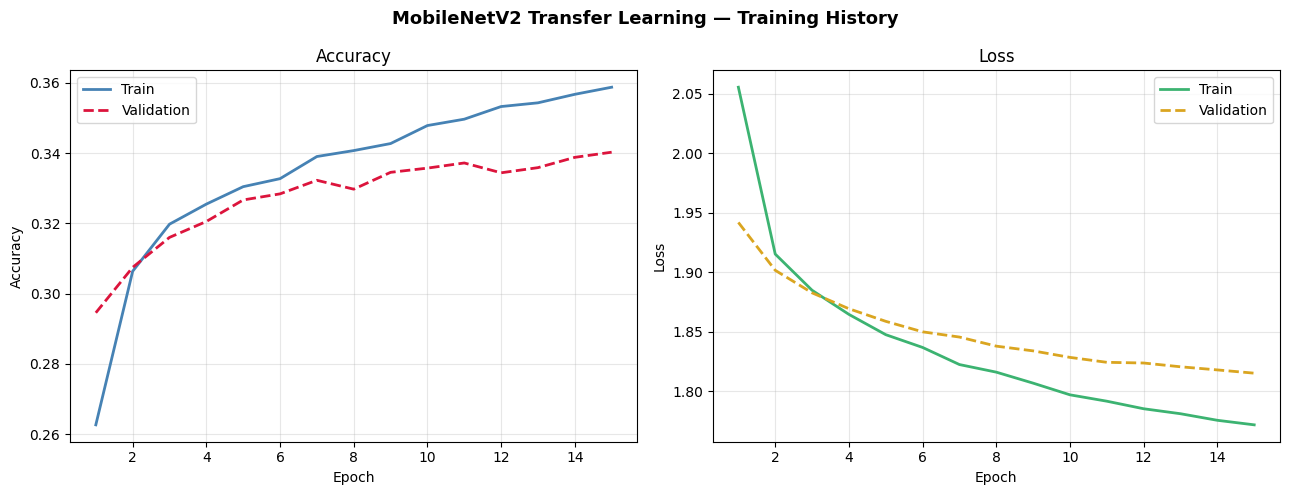

In [18]:
ep2 = range(1, len(tl_log.history['loss']) + 1)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('MobileNetV2 Transfer Learning — Training History', fontsize=13, fontweight='bold')

ax3.plot(ep2, tl_log.history['accuracy'],    color='steelblue',  lw=2, label='Train')
ax3.plot(ep2, tl_log.history['val_accuracy'], color='crimson',    lw=2, linestyle='--', label='Validation')
ax3.set_title('Accuracy')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.legend()
ax3.grid(alpha=0.3)

ax4.plot(ep2, tl_log.history['loss'],     color='mediumseagreen', lw=2, label='Train')
ax4.plot(ep2, tl_log.history['val_loss'], color='goldenrod',       lw=2, linestyle='--', label='Validation')
ax4.set_title('Loss')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()